# Bài tập về nhà Decision Tree, Random Forest


- Thực hiện các yêu cầu dưới đây với tập dữ liệu Australian credit
- Down dữ liệu tại đường link dưới đây và đặt vào folder /data
 
  https://archive.ics.uci.edu/ml/datasets/Statlog+(Australian+Credit+Approval)
    

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from matplotlib import pyplot as plt

random_state = 0


## 1. Tìm hiểu dữ liệu

In [2]:
'''
- Tìm hiểu cấu trúc data tại trang web UCI
- Down các files, đặt trong folder data/
- Chú ý:
    - Đọc mô tả dữ liệu trong file 'australian.doc'
    - Kiểm tra DecisionTree/RandomForest của Sklearn có hỗ trợ với kiểu dữ liệu được cung cấp không
'''
data_path = './data/australian.dat'
data = np.genfromtxt(data_path)
data = pd.DataFrame(data)
data.columns = [f'A{i+1}' for i in range(data.shape[1])]
X = data.drop(columns=['A15'])
y = data['A15']
print(X.head())
print(y.head())

    A1     A2     A3   A4   A5   A6     A7   A8   A9   A10  A11  A12    A13  \
0  1.0  22.08  11.46  2.0  4.0  4.0  1.585  0.0  0.0   0.0  1.0  2.0  100.0   
1  0.0  22.67   7.00  2.0  8.0  4.0  0.165  0.0  0.0   0.0  0.0  2.0  160.0   
2  0.0  29.58   1.75  1.0  4.0  4.0  1.250  0.0  0.0   0.0  1.0  2.0  280.0   
3  0.0  21.67  11.50  1.0  5.0  3.0  0.000  1.0  1.0  11.0  1.0  2.0    0.0   
4  1.0  20.17   8.17  2.0  6.0  4.0  1.960  1.0  1.0  14.0  0.0  2.0   60.0   

      A14  
0  1213.0  
1     1.0  
2     1.0  
3     1.0  
4   159.0  
0    0.0
1    0.0
2    0.0
3    1.0
4    1.0
Name: A15, dtype: float64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=random_state)

## 2. Decision Tree

### 2.1. Khảo sát các giá trị khác nhau của max_depth

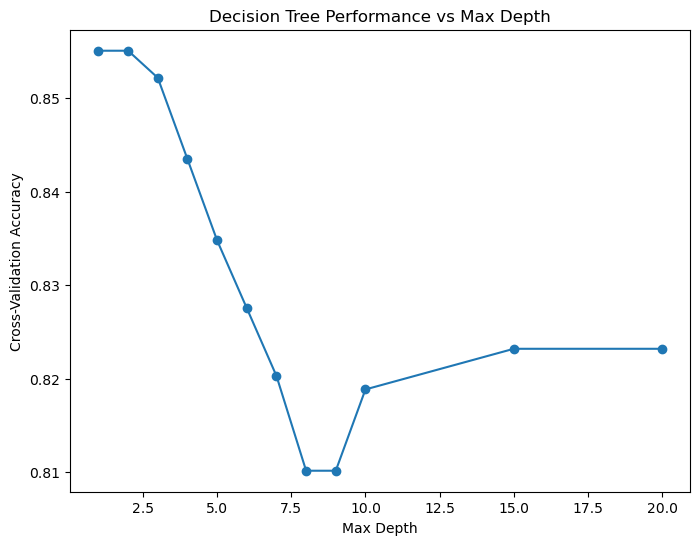

In [4]:
# code
max_depth_values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 15, 20]
acc_by_max_depth = []
for max_depth in max_depth_values:
    dt = DecisionTreeClassifier(max_depth=max_depth, random_state=random_state)
    val_score = cross_val_score(estimator=dt, X=X, y=y, cv=5, scoring='accuracy')
    acc_by_max_depth.append(val_score.mean())

plt.figure(figsize=(8, 6))
plt.plot(max_depth_values, acc_by_max_depth, marker='o')
plt.xlabel('Max Depth')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Decision Tree Performance vs Max Depth')
plt.show()

### 2.2. Tìm kiếm siêu tham số

In [5]:
parameter={
    'max_depth': [2, 3, 4, 5, 6, 7],
    'min_samples_split' : np.arange(2,202,20),
    'min_samples_leaf' : np.arange(1,201,20),
    'max_leaf_nodes': (2, 5, 10, 20, 50),
    'class_weight': ['balanced', None]
}
grid=GridSearchCV(estimator=DecisionTreeClassifier(random_state=random_state), param_grid=parameter, cv=5)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
best_dt = grid.best_estimator_
y_pred = best_dt.predict(X_test)
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Best parameters: {'class_weight': None, 'max_depth': 4, 'max_leaf_nodes': 5, 'min_samples_leaf': np.int64(1), 'min_samples_split': np.int64(2)}
Test Accuracy: 0.8623188405797102


## 3. Random Forest

### 3.1 Khảo sát các giá trị khác nhau của n_estimators

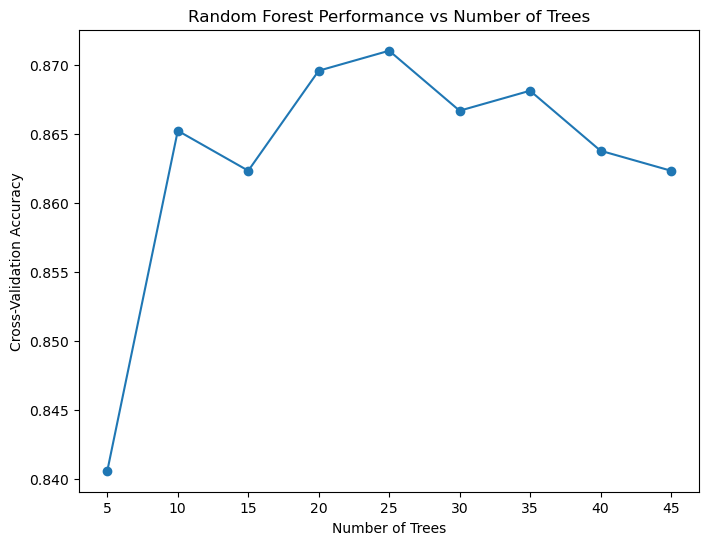

In [6]:
num_trees = np.arange(5, 50, 5)
acc_by_num_trees = []
for num in num_trees:
    rf = RandomForestClassifier(n_estimators=num, random_state=random_state)
    val_score = cross_val_score(estimator=rf, X=X, y=y, cv=5, scoring='accuracy')
    acc_by_num_trees.append(val_score.mean())
plt.figure(figsize=(8,6))
plt.plot(num_trees, acc_by_num_trees, marker='o')
plt.xlabel('Number of Trees')
plt.ylabel('Cross-Validation Accuracy')
plt.title('Random Forest Performance vs Number of Trees')
plt.show()

### 3.2 Tìm kiếm siêu tham số

In [10]:
parameter={
    'max_depth': [2,3,5,7,10, 20],
    'min_samples_leaf': [1,10,30,60],
    'max_features': [1.0,'log2','sqrt'],
    'n_estimators': [1,2,3,5,10, 20, 50, 100,170]
    }
grid=GridSearchCV(RandomForestClassifier(random_state=random_state), param_grid=parameter,n_jobs=-1, verbose=1)
grid.fit(X_train,y_train)
print(grid.best_params_)
y_pred = grid.predict(X_test)
print(accuracy_score(y_test, y_pred))

Fitting 5 folds for each of 648 candidates, totalling 3240 fits
{'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'n_estimators': 170}
0.8840579710144928
